In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

ORANGE = '#FF6B35'
DARK   = '#1A1A2E'
GREEN  = '#10B981'
RED    = '#EF4444'
BLUE   = '#3B82F6'

conn = mysql.connector.connect(
    host='localhost', user='root',
    password='0987654321', database='datamart_rappi'
)

df = pd.read_sql("""
    SELECT f.tiempo_total_min, f.minutos_retraso,
           f.dist_asignacion_km, f.tiempo_espera_rest_min,
           f.cumple_sla, f.valor_pedido_soles,
           t.hora_dia, t.dia_semana, t.franja, t.es_hora_pico,
           z.distrito, z.avenida_principal,
           r.nombre_sucursal,
           rep.modalidad_reparto, rep.calificacion_repartidor
    FROM fact_pedidos f
    LEFT JOIN dim_tiempo t ON f.id_tiempo = t.id_tiempo
    LEFT JOIN dim_zona z ON f.id_zona = z.id_zona
    LEFT JOIN dim_restaurante r ON f.id_restaurante = r.id_restaurante
    LEFT JOIN dim_repartidor rep ON f.id_repartidor = rep.id_repartidor
""", conn)
conn.close()

print(f' Datos cargados: {df.shape[0]:,} registros | {df.shape[1]} variables')

 Datos cargados: 10,000 registros | 15 variables


C:\Users\Admin\AppData\Local\Temp\ipykernel_4516\2884188473.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


In [4]:
# CELDA 1 --- Estadística Descriptiva
vars_num = ['tiempo_total_min', 'minutos_retraso',
            'dist_asignacion_km', 'tiempo_espera_rest_min']

desc = df[vars_num].describe().round(2)
desc.index = ['Conteo','Media','Std','Mínimo','Q1 (25%)','Mediana','Q3 (75%)','Máximo']
desc.columns = ['T.Entrega (min)','Retraso (min)','Distancia (km)','Espera Rest. (min)']

print('=' * 60)
print('ESTADÍSTICA DESCRIPTIVA — RAPPI LOS OLIVOS')
print('=' * 60)
print(desc.to_string())

print(f'\n Distribución SLA:')
print(f'  Cumple SLA:    {df["cumple_sla"].sum():,} ({df["cumple_sla"].mean()*100:.2f}%)')
print(f'  No cumple SLA: {(~df["cumple_sla"].astype(bool)).sum():,} ({(1-df["cumple_sla"].mean())*100:.2f}%)')

print(f'\n Valores nulos:')
nulos = df[vars_num].isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '   Sin valores nulos')

ESTADÍSTICA DESCRIPTIVA — RAPPI LOS OLIVOS
          T.Entrega (min)  Retraso (min)  Distancia (km)  Espera Rest. (min)
Conteo           10000.00       10000.00        10000.00            10000.00
Media               17.66           0.27            1.43                9.61
Std                  7.20           1.23            0.75                4.74
Mínimo               5.00           0.00            0.02                0.00
Q1 (25%)            12.50           0.00            0.94                6.30
Mediana             16.30           0.00            1.33                9.20
Q3 (75%)            21.60           0.00            1.70               12.40
Máximo              48.10          18.10            4.15               32.60

 Distribución SLA:
  Cumple SLA:    9,242 (92.42%)
  No cumple SLA: 758 (7.58%)

 Valores nulos:
   Sin valores nulos


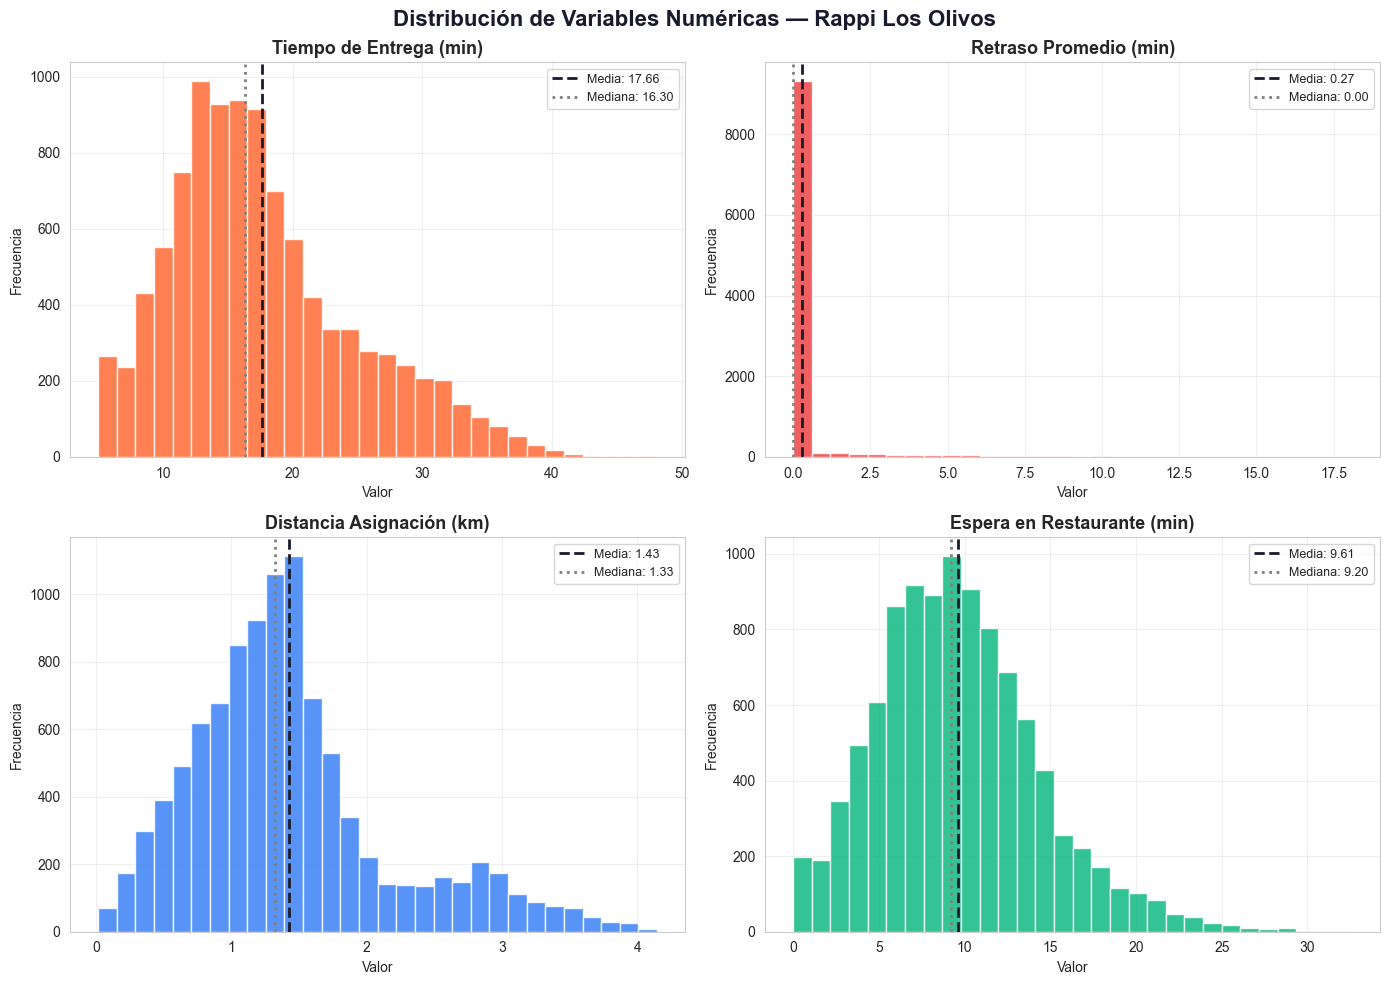

 Guardado: imagenes/eda_histogramas.png


In [5]:
# CELDA 2 --- Histogramas

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Numéricas — Rappi Los Olivos',
             fontsize=16, fontweight='bold', color=DARK)

configs = [
    ('tiempo_total_min', 'Tiempo de Entrega (min)', ORANGE, axes[0,0]),
    ('minutos_retraso', 'Retraso Promedio (min)', RED, axes[0,1]),
    ('dist_asignacion_km', 'Distancia Asignación (km)', BLUE, axes[1,0]),
    ('tiempo_espera_rest_min', 'Espera en Restaurante (min)', GREEN, axes[1,1]),
]

for col, titulo, color, ax in configs:
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color=DARK, linestyle='--',
               linewidth=2, label=f'Media: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='gray', linestyle=':',
               linewidth=2, label=f'Mediana: {df[col].median():.2f}')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('imagenes/eda_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: imagenes/eda_histogramas.png')

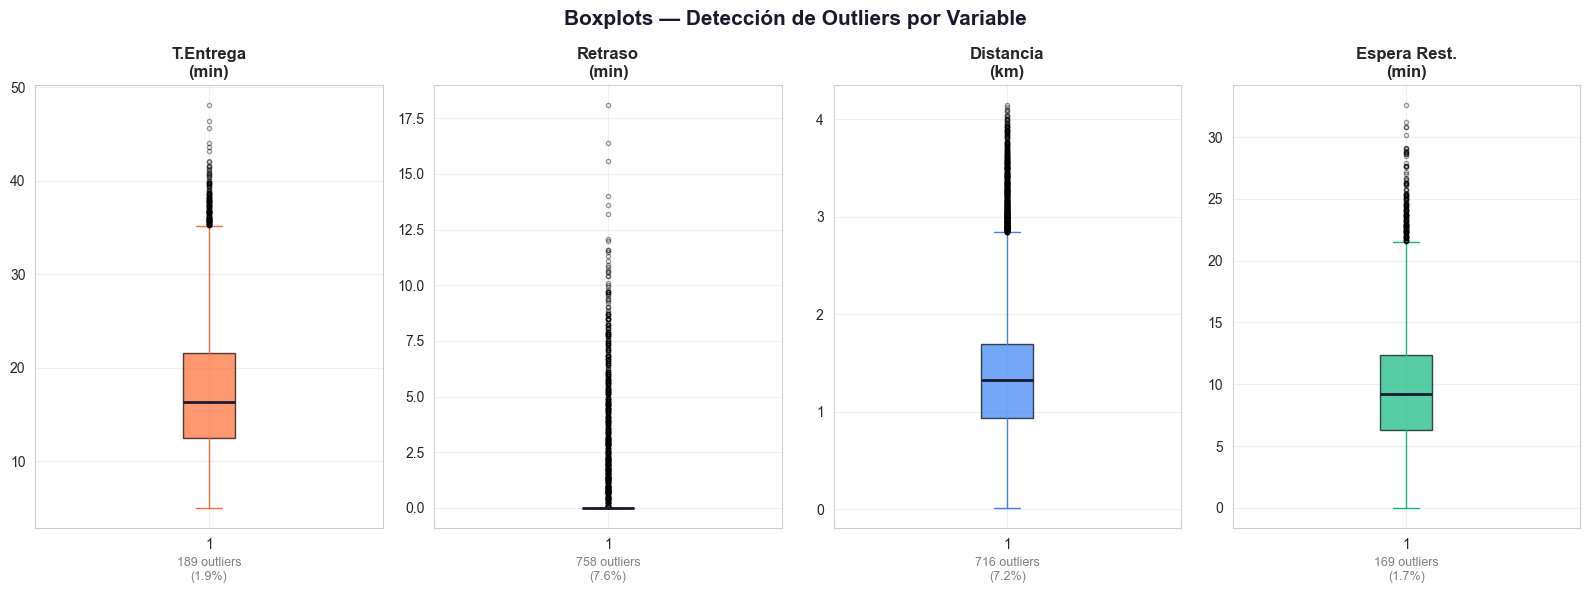

 Guardado: imagenes/eda_boxplots.png


In [6]:
# CELDA 3 --- Boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle('Boxplots — Detección de Outliers por Variable',
             fontsize=15, fontweight='bold', color=DARK)

colores = [ORANGE, RED, BLUE, GREEN]
labels  = ['T.Entrega\n(min)', 'Retraso\n(min)',
           'Distancia\n(km)', 'Espera Rest.\n(min)']

for i, (col, label, color) in enumerate(zip(vars_num, labels, colores)):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.7),
        medianprops=dict(color=DARK, linewidth=2),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', color=color, alpha=0.4, markersize=3))
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)].shape[0]
    pct = outliers/len(df)*100
    axes[i].set_xlabel(f'{outliers} outliers\n({pct:.1f}%)', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('imagenes/eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: imagenes/eda_boxplots.png')

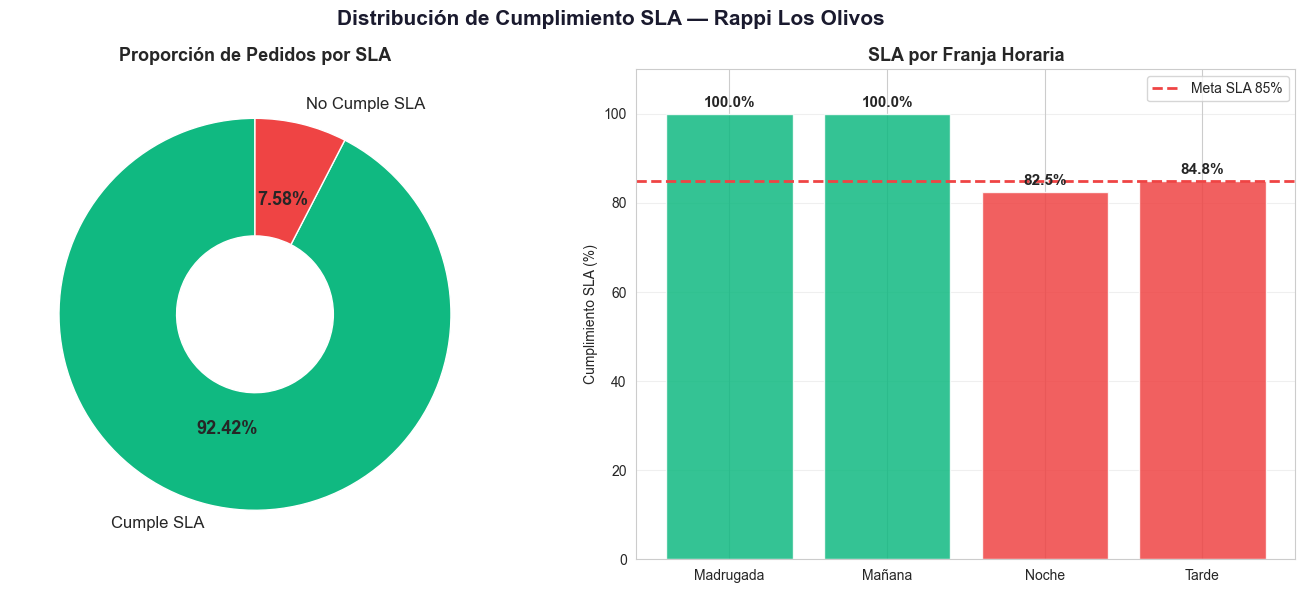

 Guardado: imagenes/eda_distribucion_sla.png


In [7]:
# CELDA 4 --- Distribución SLA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribución de Cumplimiento SLA — Rappi Los Olivos',
             fontsize=15, fontweight='bold', color=DARK)

cumple = df['cumple_sla'].sum()
no_cumple = len(df) - cumple

wedges, texts, autotexts = ax1.pie(
    [cumple, no_cumple],
    labels=['Cumple SLA', 'No Cumple SLA'],
    colors=[GREEN, RED],
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops=dict(width=0.6),
    textprops=dict(fontsize=12)
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)
ax1.set_title('Proporción de Pedidos por SLA', fontsize=13, fontweight='bold')

if 'franja' in df.columns:
    sla_franja = df.groupby('franja')['cumple_sla'].mean() * 100
    colores_franja = [GREEN if v >= 85 else RED for v in sla_franja.values]
    bars = ax2.bar(sla_franja.index, sla_franja.values,
                   color=colores_franja, edgecolor='white', alpha=0.85)
    ax2.axhline(y=85, color=RED, linestyle='--', linewidth=2, label='Meta SLA 85%')
    ax2.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')
    ax2.set_title('SLA por Franja Horaria', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Cumplimiento SLA (%)')
    ax2.set_ylim(0, 110)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('imagenes/eda_distribucion_sla.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: imagenes/eda_distribucion_sla.png')

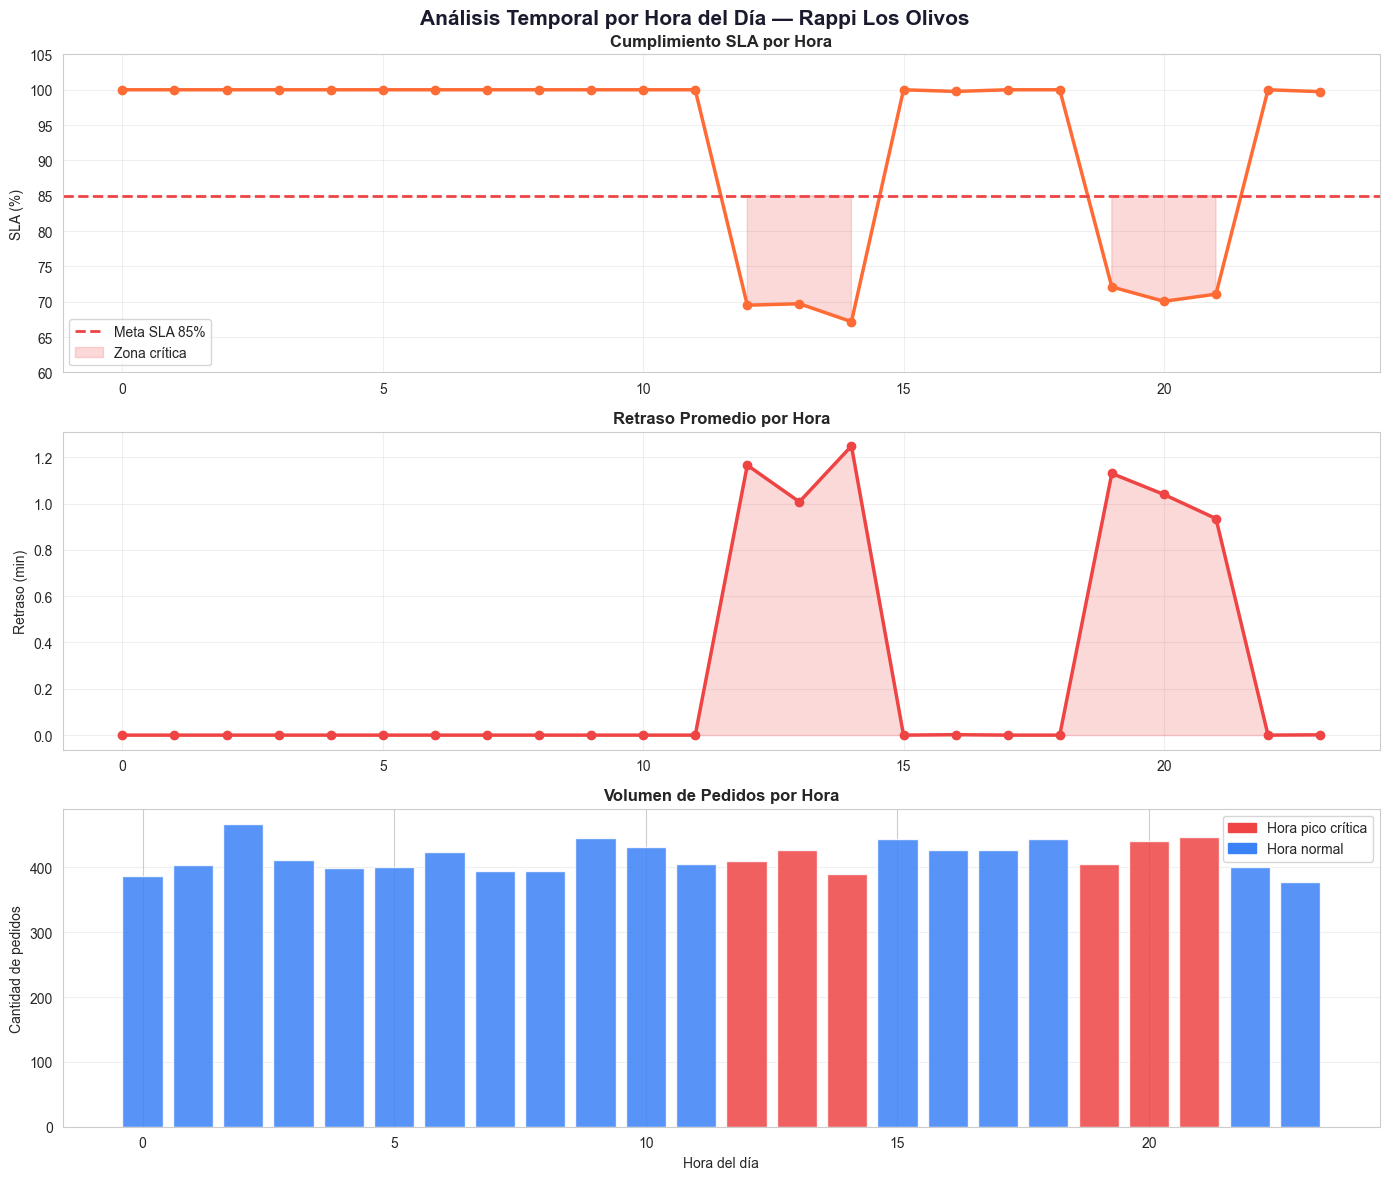

 Guardado: imagenes/eda_analisis_temporal.png


In [8]:
# CELDA 5 --- Análisis por Hora
if 'hora_dia' in df.columns:
    sla_hora = df.groupby('hora_dia')['cumple_sla'].mean() * 100
    retraso_hora = df.groupby('hora_dia')['minutos_retraso'].mean()
    volumen_hora = df.groupby('hora_dia').size()

    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle('Análisis Temporal por Hora del Día — Rappi Los Olivos',
                 fontsize=15, fontweight='bold', color=DARK)

    axes[0].plot(sla_hora.index, sla_hora.values, color=ORANGE,
                 linewidth=2.5, marker='o', markersize=6)
    axes[0].axhline(y=85, color=RED, linestyle='--',
                    linewidth=2, label='Meta SLA 85%')
    axes[0].fill_between(sla_hora.index, sla_hora.values, 85,
                         where=(sla_hora.values < 85),
                         color=RED, alpha=0.2, label='Zona crítica')
    axes[0].set_title('Cumplimiento SLA por Hora', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('SLA (%)')
    axes[0].set_ylim(60, 105)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(retraso_hora.index, retraso_hora.values, color=RED,
                 linewidth=2.5, marker='o', markersize=6)
    axes[1].fill_between(retraso_hora.index, retraso_hora.values,
                         alpha=0.2, color=RED)
    axes[1].set_title('Retraso Promedio por Hora', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Retraso (min)')
    axes[1].grid(True, alpha=0.3)

    colores_vol = [RED if (12<=h<=14 or 19<=h<=21) else BLUE
                   for h in volumen_hora.index]
    axes[2].bar(volumen_hora.index, volumen_hora.values,
                color=colores_vol, edgecolor='white', alpha=0.85)
    axes[2].set_title('Volumen de Pedidos por Hora', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Cantidad de pedidos')
    axes[2].set_xlabel('Hora del día')
    axes[2].grid(True, alpha=0.3, axis='y')

    from matplotlib.patches import Patch
    leyenda = [Patch(color=RED, label='Hora pico crítica'),
               Patch(color=BLUE, label='Hora normal')]
    axes[2].legend(handles=leyenda)

    plt.tight_layout()
    plt.savefig('imagenes/eda_analisis_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Guardado: imagenes/eda_analisis_temporal.png')

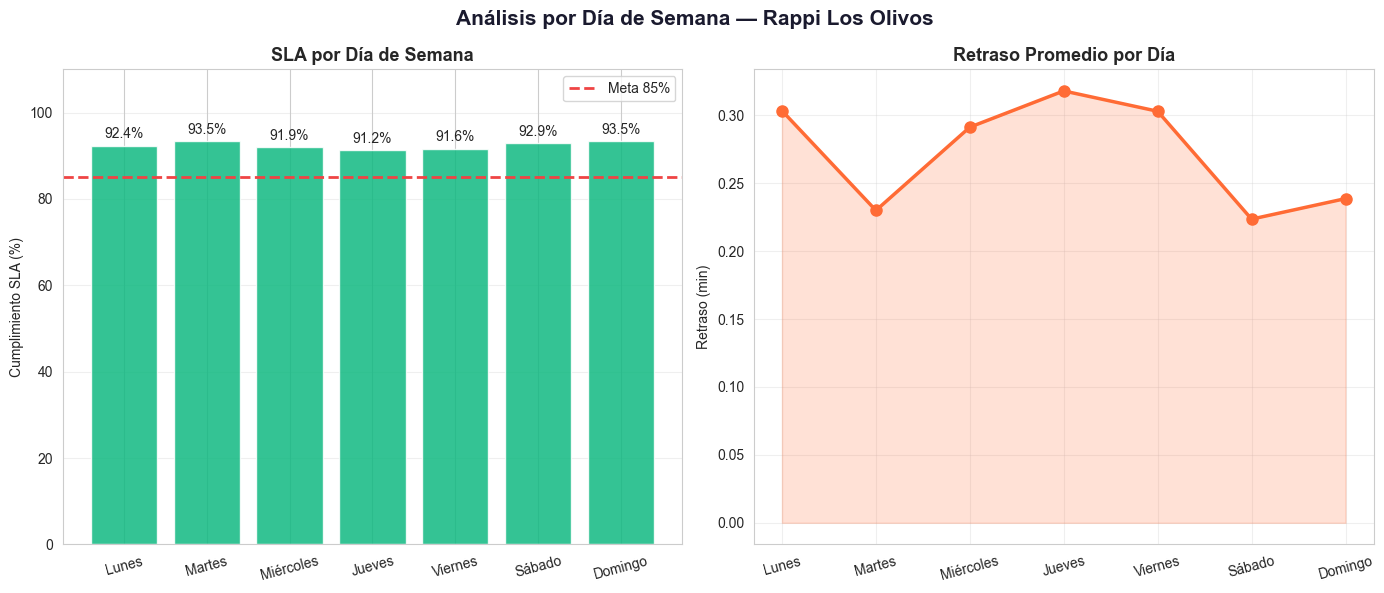

 Guardado: imagenes/eda_analisis_semanal.png


In [9]:
# CELDA 6 --- Análisis por Día de Semana
if 'dia_semana' in df.columns:
    orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    nombres_dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

    sla_dia = df.groupby('dia_semana')['cumple_sla'].mean() * 100
    sla_dia = sla_dia.reindex([d for d in orden_dias if d in sla_dia.index])
    retraso_dia = df.groupby('dia_semana')['minutos_retraso'].mean()
    retraso_dia = retraso_dia.reindex([d for d in orden_dias if d in retraso_dia.index])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Análisis por Día de Semana — Rappi Los Olivos',
                 fontsize=15, fontweight='bold', color=DARK)

    colores_dias = [RED if v < 85 else GREEN for v in sla_dia.values]
    bars1 = ax1.bar(range(len(sla_dia)), sla_dia.values,
                    color=colores_dias, edgecolor='white', alpha=0.85)
    ax1.axhline(y=85, color=RED, linestyle='--', linewidth=2, label='Meta 85%')
    ax1.set_xticks(range(len(sla_dia)))
    ax1.set_xticklabels(nombres_dias[:len(sla_dia)], rotation=15)
    ax1.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=10)
    ax1.set_title('SLA por Día de Semana', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Cumplimiento SLA (%)')
    ax1.set_ylim(0, 110)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    ax2.plot(range(len(retraso_dia)), retraso_dia.values,
             color=ORANGE, linewidth=2.5, marker='o', markersize=8)
    ax2.fill_between(range(len(retraso_dia)), retraso_dia.values,
                     alpha=0.2, color=ORANGE)
    ax2.set_xticks(range(len(retraso_dia)))
    ax2.set_xticklabels(nombres_dias[:len(retraso_dia)], rotation=15)
    ax2.set_title('Retraso Promedio por Día', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Retraso (min)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('imagenes/eda_analisis_semanal.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Guardado: imagenes/eda_analisis_semanal.png')

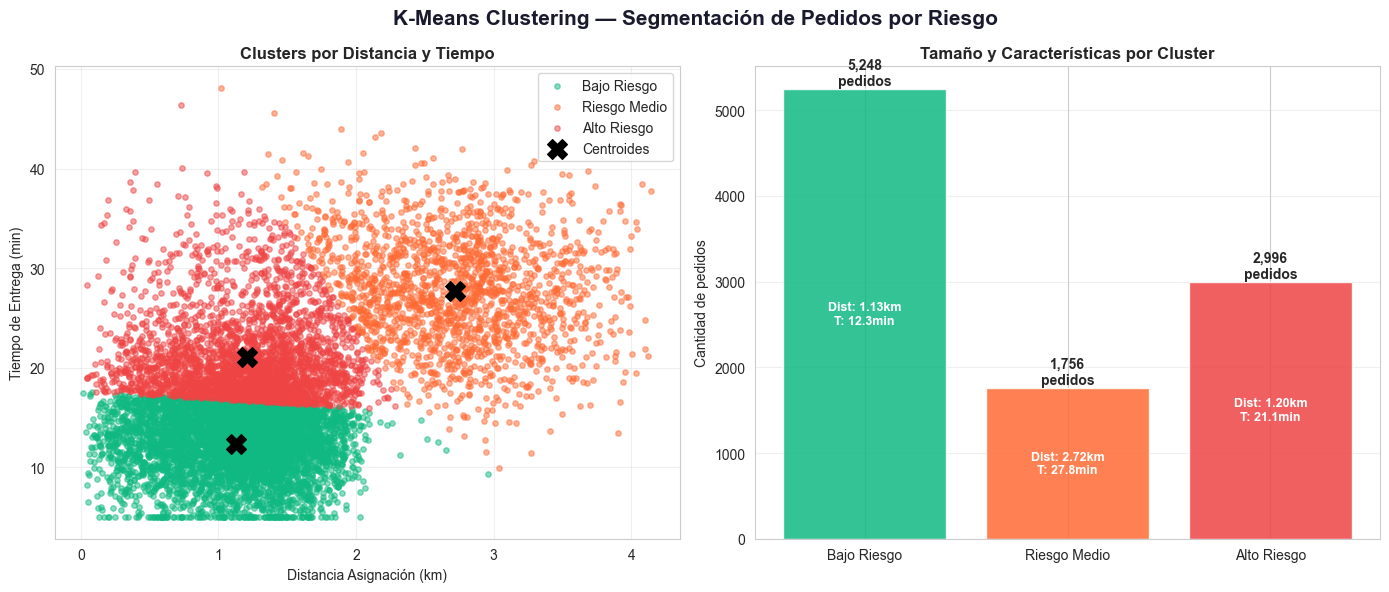


Resumen por Cluster:
  Bajo Riesgo: 5,248 pedidos | Dist: 1.13km | Tiempo: 12.3min
  Riesgo Medio: 1,756 pedidos | Dist: 2.72km | Tiempo: 27.8min
  Alto Riesgo: 2,996 pedidos | Dist: 1.20km | Tiempo: 21.1min
Guardado: imagenes/eda_kmeans_clusters.png


In [12]:
# CELDA 7 --- K-Means Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[['dist_asignacion_km', 'tiempo_total_min']].dropna()

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features = features.copy()
features['cluster'] = kmeans.fit_predict(features_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('K-Means Clustering — Segmentación de Pedidos por Riesgo',
             fontsize=15, fontweight='bold', color=DARK)

colores_cluster = [GREEN, ORANGE, RED]
labels_cluster = ['Bajo Riesgo', 'Riesgo Medio', 'Alto Riesgo']

for i in range(3):
    mask = features['cluster'] == i
    ax1.scatter(features[mask]['dist_asignacion_km'],
                features[mask]['tiempo_total_min'],
                c=colores_cluster[i], label=labels_cluster[i],
                alpha=0.5, s=15)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
ax1.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroides')
ax1.set_title('Clusters por Distancia y Tiempo', fontsize=12, fontweight='bold')
ax1.set_xlabel('Distancia Asignación (km)')
ax1.set_ylabel('Tiempo de Entrega (min)')
ax1.legend()
ax1.grid(True, alpha=0.3)

conteo = features['cluster'].value_counts().sort_index()
resumen = features.groupby('cluster')[['dist_asignacion_km','tiempo_total_min']].mean().round(2)
ax2.bar(labels_cluster, conteo.values,
        color=colores_cluster, edgecolor='white', alpha=0.85)
for i, (v, res) in enumerate(zip(conteo.values, resumen.values)):
    ax2.text(i, v + 50, f'{v:,}\npedidos', ha='center',
             fontsize=10, fontweight='bold')
    ax2.text(i, v/2, f'Dist: {res[0]:.2f}km\nT: {res[1]:.1f}min',
             ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax2.set_title('Tamaño y Características por Cluster', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cantidad de pedidos')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('imagenes/eda_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResumen por Cluster:')
for i in range(3):
    mask = features['cluster'] == i
    print(f'  {labels_cluster[i]}: {mask.sum():,} pedidos | '
          f'Dist: {features[mask]["dist_asignacion_km"].mean():.2f}km | '
          f'Tiempo: {features[mask]["tiempo_total_min"].mean():.1f}min')
print('Guardado: imagenes/eda_kmeans_clusters.png')